 # DESCARGA Y EXPLORACIÓN INICIAL DE DATOS FINANCIEROS DE PYTHON.

MAGALY BENAVIDES SANTIAGO

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

In [2]:
print('Version de pandas:', pd.__version__)

Version de pandas: 1.4.3


In [3]:
print('Version de yfinance:', yf.__version__)

Version de yfinance: 0.2.57


In [4]:
ticket = 'SPY'

In [5]:
fecha_inicio = '2015-01-01'

In [6]:
fecha_fin = '2026-01-01'

In [7]:
datos = yf.download(ticket, start=fecha_inicio, end= fecha_fin, interval='1d', auto_adjust=False, multi_level_index=False, progress=False)

In [8]:
if datos.empty:
    raise ValueError(
    'NO SE DESCARGARON LOS DATOS, REVISE EL TICKET,' ' LAS FECHAS Y LA CONEXION A INTERNET')
print ('la descarga se realizo correctamente')

la descarga se realizo correctamente


In [9]:
type(datos)

pandas.core.frame.DataFrame

In [10]:
datos.shape

(2766, 6)

In [12]:
datos.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,169.687836,205.429993,206.880005,204.179993,206.380005,121465900
2015-01-05,166.623337,201.720001,204.369995,201.350006,204.169998,169632600
2015-01-06,165.053909,199.820007,202.720001,198.860001,202.089996,209151400
2015-01-07,167.110703,202.309998,202.720001,200.880005,201.419998,125346700
2015-01-08,170.076080,205.899994,206.160004,203.990005,204.009995,147217800


In [13]:
datos.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-24,686.730530,690.380005,690.830017,687.799988,687.950012,39445600
2025-12-26,686.660889,690.309998,691.659973,689.270020,690.640015,41613300
2025-12-29,684.213867,687.849976,689.200012,686.070007,687.539978,62559500
2025-12-30,683.378296,687.010010,688.559998,686.580017,687.450012,47160700
2025-12-31,678.315247,681.919983,687.359985,681.710022,687.140015,74144800


In [14]:
datos.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [15]:
datos.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=2766, freq=None)

In [16]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2766 non-null   float64
 1   Close      2766 non-null   float64
 2   High       2766 non-null   float64
 3   Low        2766 non-null   float64
 4   Open       2766 non-null   float64
 5   Volume     2766 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 151.3 KB


In [19]:
print('Tipo de indice:', type(datos.index))
print('Primera fecha:', datos.index.min())
print('Ultima fecha:', datos.index.max())
print('Numero de observaciones:', len(datos))

Tipo de indice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Primera fecha: 2015-01-02 00:00:00
Ultima fecha: 2025-12-31 00:00:00
Numero de observaciones: 2766


In [20]:
print('Las fechas estan ordenadas:', datos.index.is_monotonic_increasing) #True: las fechas aparecen de las antigua a la mas reciente

Las fechas estan ordenadas: True


In [23]:
#DIFERENCIAS ENTRE FECHAS CONSECUTVIAS 
diferencias_fechas=datos.index.to_series().diff()
frecuencia_observada=(diferencias_fechas.value_counts().sort_index())
frecuencia_observada

1 days    2164
2 days      27
3 days     498
4 days      76
Name: Date, dtype: int64

In [25]:
#DIAS ENTEROS: CUANTAS SEPARACIONES SON DE UNO, DOS, TRES O MAS DIAS
diferencias_en_dias = diferencias_fechas.dt.days
diferencias_en_dias.value_counts().sort_index()

1.0    2164
2.0      27
3.0     498
4.0      76
Name: Date, dtype: int64

In [26]:
#IDENTIFICA EL DIA DE LA SEMANA
dias_semana=pd.Series(datos.index.day_name(),index = datos.index)
dias_semana.value_counts()

Tuesday      570
Wednesday    567
Thursday     557
Friday       555
Monday       517
Name: Date, dtype: int64

In [27]:
#OBSERVACIONES EN SABADO O DOMINGO
fin_de_semana= datos.index.dayofweek >=5
print('Observaciones en sabado o domingo', fin_de_semana.sum())

Observaciones en sabado o domingo 0


In [28]:
#VALORES FALTANTES POR COLUMNAS
datos.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [30]:
revision_de_faltantes=pd.DataFrame({'Valores faltantes':datos.isna().sum(),'Porcentaje': 100*datos.isna().mean()})
revision_de_faltantes

,Valores faltantes,Porcentaje
Adj Close,0,0.0
Close,0,0.0
High,0,0.0
Low,0,0.0
Open,0,0.0
Volume,0,0.0


In [31]:
#FECHAS DUPLICADAS
numero_duplicadas=datos.index.duplicated().sum()
print('Numero de fechas ducplicadas:', numero_duplicadas)

Numero de fechas ducplicadas: 0


In [32]:
#En caso de que sea positivo, se hace lo siguiente
if numero_duplicadas > 0:
    display(datos[datos.index.duplicated(keep=False)])

In [35]:
#PRECIOS POSITIVOS
columnas_precios= ['Open', 'High', 'Low','Close','Adj Close']
(datos[columnas_precios] <= 0).sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
dtype: int64

In [37]:
#maximo diario no puede ser menor que el minimo diario
print('Dias con High menor que low:', (datos['High'] < datos['Low']).sum())

Dias con High menor que low: 0


In [40]:
#APERTURA FUERA DEL INTERVALO DIARIO
apertura_inconsistente=((datos['Open'] < datos["Low"]) | (datos['Open'] > datos["High"]))
print ('Apertura fuera del intervalo Low-Higt:', apertura_inconsistente.sum())

Apertura fuera del intervalo Low-Higt: 0


In [41]:
cierre_inconsistente=((datos['Close'] < datos["Low"]) | (datos['Close'] > datos["High"]))
print ('Cierres fuera del intervalo Low-Higt:', cierre_inconsistente.sum())

Cierres fuera del intervalo Low-Higt: 0


In [43]:
#VOLUMEN NEGATIVO
print('Observaciones con numero negativo:', (datos['Volume']<0).sum())

Observaciones con numero negativo: 0


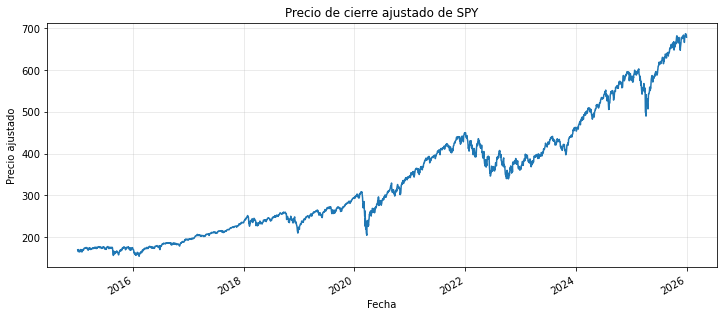

In [44]:
#PRECIO DE CIERRE AJUSTADO
ax= datos['Adj Close'].plot(figsize=(12,5), title= 'Precio de cierre ajustado de SPY')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ajustado')
ax.grid(alpha=0.3)
plt.show()

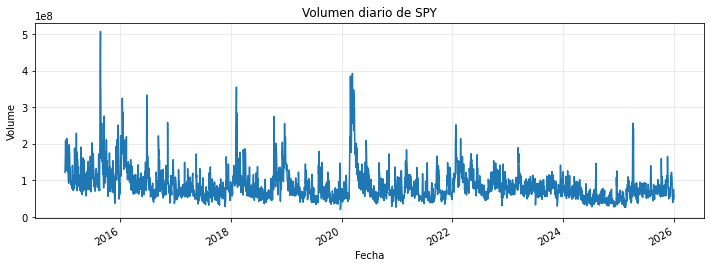

In [45]:
#GRAFICA DE VOLUMEN DIARIO
ax= datos['Volume'].plot(figsize=(12,4), title= 'Volumen diario de SPY')
ax.set_xlabel('Fecha')
ax.set_ylabel('Volume')
ax.grid(alpha=0.3)
plt.show()

In [60]:
#RESUMEN AUTOMATICO
resumen_descarga= pd.DataFrame({
'Elemento':['Ticket','Fecha inicial solicitada', 'Fecha final exclusiva solicitada','Primera fecha disponible','Ultima fecha disponible', 'Numero de observaciones','Numero de columnas', 'Total de valores faltantes','Fechas duplicadas', 'Fechas ordenadas'] ,
'Resultado': [ticket,fecha_inicio, fecha_fin, datos.index.min().strftime('%Y-%m-%d'),datos.index.max().strftime('%Y-%m-%d'),len(datos),datos.shape[1], datos.isna().sum().sum(),datos.index.duplicated().sum(),datos.index.is_monotonic_increasing] 
})
resumen_descarga

,Elemento,Resultado
0,Ticket,SPY
1,Fecha inicial solicitada,2015-01-01
2,Fecha final exclusiva solicitada,2026-01-01
3,Primera fecha disponible,2015-01-02
4,Ultima fecha disponible,2025-12-31
5,Numero de observaciones,2766
6,Numero de columnas,6
7,Total de valores faltantes,0
8,Fechas duplicadas,0
9,Fechas ordenadas,True


In [62]:
#PARA CONSERVACION DE DATOS ORIGINALES
ruta_raw=Path('data/raw')
ruta_raw.mkdir(parents=True, exist_ok=True)

In [64]:
#Datos sin limpiar (raw)
archivo_salida = ruta_raw / 'SPY_2015_2025_raw.csv'
datos.to_csv(archivo_salida)
print("Archivo guardado en:", archivo_salida)

Archivo guardado en: data\raw\SPY_2015_2025_raw.csv


In [66]:
#RECUPERACION DEL ARCHIVO
datos_recuperados= pd.read_csv(archivo_salida, index_col=0, parse_dates=True)
datos_recuperados.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,169.687836,205.429993,206.880005,204.179993,206.380005,121465900
2015-01-05,166.623337,201.720001,204.369995,201.350006,204.169998,169632600
2015-01-06,165.053909,199.820007,202.720001,198.860001,202.089996,209151400
2015-01-07,167.110703,202.309998,202.720001,200.880005,201.419998,125346700
2015-01-08,170.076080,205.899994,206.160004,203.990005,204.009995,147217800


In [67]:
#COMPARAR DIMENSIONES
print("Dimensiones originales:", datos.shape)
print("Dimensiones recuperadas:", datos_recuperados.shape)

Dimensiones originales: (2766, 6)
Dimensiones recuperadas: (2766, 6)


In [70]:
assert datos.shape == datos_recuperados.shape
print("El archivo se guardo y se recupero correctamente")

El archivo se guardo y se recupero correctamente


COMO FUE LA COBERTURA Y CALIDAD DE LA BASE?

La realizó la serie histórica del ETF SPY, descargada mediante la librería 'yfinance', confirma una estructura de datos sólida, completa y libre de anomalías evidentes. El periodo analizado abarca desde el 2 de enero de 2015 hasta el 31 de diciembre de 2025.  La ausencia del 1 de enero en el registro inicial responde al calendario oficial del mercado bursátil estadounidense por ser día festivo, por lo que la cobertura temporal satisface de manera estricta el intervalo de diez años solicitado en los parámetros del proyecto. 

La base contiene un total de 2,766 observaciones y 6 columnas. La verificación con 'datos.isna().sum()' reflejó un 0% de valores faltantes en todas las variables. Asimismo, el conteo de fechas duplicadas en el 'DatetimeIndex' dio como resultado cero, y la prueba de ordenamiento confirmó una secuencia cronológica. 
Respecto a los precios diarios, la base superó con éxito todas las pruebas de validación: no se identificaron precios negativos, la condición High y Low se cumplió en la totalidad de las sesiones, y los precios de apertura y cierre se mantuvieron siempre dentro de sus respectivas fructuaciones respectivas. Finalmente, el archivo original fue almacenado e importado con éxito desde la ruta 'data/raw/SPY_2015_2025_raw.csv', verificando la preservación exacta de sus dimensiones. La serie se encuentra completamente documentada y lista para su fase de limpieza formal en la Semana 4.